# Hourly bike-sharing demand — time-series probabilistic forecast

Real time series: 17 379 hourly rows from a DC bike-share system
(2011–2012). Target = hourly rental count. We use **expanding-window CV**
(train always precedes test in calendar time) and compare a learned
model against **two** baselines:

1. `EmpiricalDistribution` — marginal-y; ignores features.
2. `Persistence(lag=24)` — "same hour yesterday"; captures the diurnal
   cycle.

The interesting question isn't whether you beat the marginal baseline
(you usually do). It's whether you beat **the seasonal one**.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml

warnings.filterwarnings(
    "ignore", message="X does not have valid feature names.*",
    category=UserWarning,
)

from bracketlearn.adapters import BracketLadder
from bracketlearn.baselines import EmpiricalDistribution, Persistence
from bracketlearn.composite import CalibratedForecaster, LiftedForecaster
from bracketlearn.lift import GlobalResidual, Isotonic
from bracketlearn.pipeline import ForecastPipeline
from bracketlearn.score import pit
from bracketlearn.trainers import EMOS, QuantileReg

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Data

In [2]:
print("loading Bike_Sharing_Demand …")
ds = fetch_openml("Bike_Sharing_Demand", version=2,
                  as_frame=True, parser="pandas")
df: pd.DataFrame = ds.data
y_raw = ds.target.to_numpy(dtype=float)
df = df.sort_values(["year", "month", "hour"]).reset_index(drop=True)
y = y_raw[df.index.to_numpy()]


def _prepare(df: pd.DataFrame) -> np.ndarray:
    df = df.copy()
    cat_cols = [c for c in df.columns if str(df[c].dtype) == "category"]
    num_cols = [c for c in df.columns if c not in cat_cols]
    dummies = pd.get_dummies(df[cat_cols], drop_first=True).astype(float)
    X = pd.concat([df[num_cols].astype(float), dummies], axis=1)
    return X.to_numpy(dtype=float)


X = _prepare(df)
n = X.shape[0]
ids = np.arange(n)
ts = ids.astype(float)
print(f"  rows={n}  features={X.shape[1]}  y in [{y.min():.0f}, {y.max():.0f}]")

# Synthetic "ensemble" for EMOS (which expects rows × experts).
rng = np.random.default_rng(0)
temp_col = df["temp"].to_numpy(dtype=float)
X_ens = np.column_stack([
    temp_col + rng.normal(0, 1, n),
    temp_col + rng.normal(0, 2, n),
    temp_col + rng.normal(0, 0.5, n),
]) * 8.0 + 50.0

loading Bike_Sharing_Demand …
  rows=17379  features=16  y in [1, 977]


Quick look at the diurnal cycle — this is why lag-24 persistence is a
real baseline rather than a strawman:

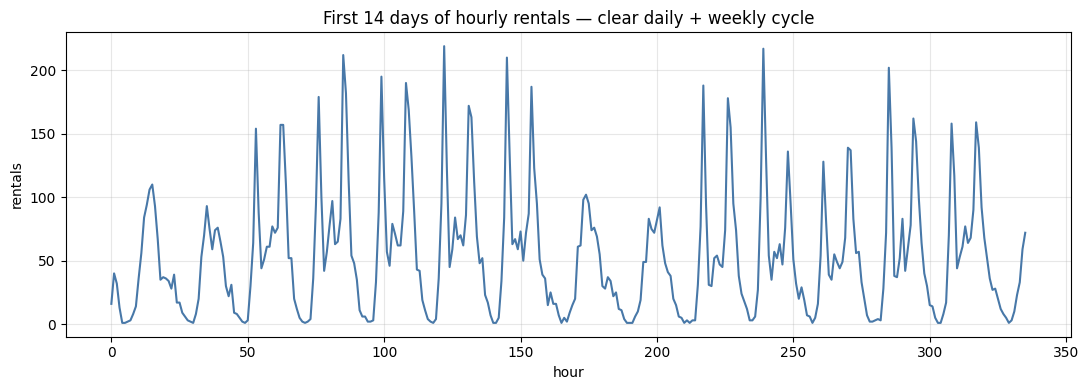

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
sample = df.iloc[:24 * 14]   # 14 days
ax.plot(sample.index, y[:24 * 14], color="#4878a8")
ax.set_xlabel("hour")
ax.set_ylabel("rentals")
ax.set_title("First 14 days of hourly rentals — clear daily + weekly cycle")
plt.tight_layout(); plt.show()

## Bracket ladder

In [4]:
edges = np.array([0., 50., 100., 200., 350., 500., 750., 1000.])
ladder = BracketLadder(edges=edges)
bracket_labels = [f"{lo:.0f}-{hi:.0f}"
                  for lo, hi in zip(edges[:-1], edges[1:], strict=True)]
print(f"{len(edges)-1} brackets covering {edges[0]:.0f}–{edges[-1]:.0f} bikes/hour")

7 brackets covering 0–1000 bikes/hour


## Pipeline: 2 baselines + 2 learned models

`embargo=24` puts a 24-row buffer between train and test in each fold,
so persistence-style leakage across the boundary is ruled out.

In [5]:
pipeline = ForecastPipeline(
    steps=[
        ("emp", EmpiricalDistribution()),
        ("persist24", LiftedForecaster(
            Persistence(lag=24), GlobalResidual(), name="persist24",
        )),
        ("emos_iso", CalibratedForecaster(
            EMOS(), Isotonic(edges=edges), name="emos_iso",
        )),
        ("qreg", QuantileReg(n_estimators=200, learning_rate=0.05, random_seed=0)),
    ],
    cv="expanding-window", n_folds=5, embargo=24,
    refit_on_full=False,
)
result = pipeline.fit_predict(X_ens, y, ids=ids, timestamps=ts)
print(result.to_table(y, metrics=["crps", "log_score", "pit"]))

stage              n_oof          crps     log_score      pit_mean       pit_std
--------------------------------------------------------------------------------
emp                14459      107.0479        6.1739        0.6061        0.3158
persist24          14459      102.1141        6.6693        0.5136        0.2704
emos_iso           14459      101.6046        7.7990        0.4707        0.3136
qreg               14459      103.4369        6.0337        0.5922        0.3277


## Skill scores vs both baselines

Two skill columns. Beating `emp` is easy (most models learn the
marginal); beating `persist24` is the real bar — it means the model
captures something beyond the daily cycle.

Empirical CRPS:  107.05
Persist-24 CRPS: 102.11

model               CRPS    vs emp    vs persist24
--------------------------------------------------
emos_iso          101.60    +0.051          +0.005
qreg              103.44    +0.034          -0.013


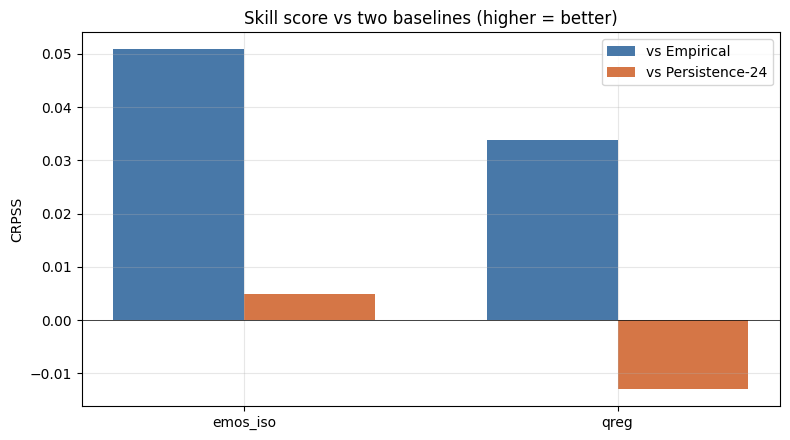

In [6]:
crps_scores = result.score(y, metrics=["crps"])
emp_c = crps_scores["emp"]["crps"]
seas_c = crps_scores["persist24"]["crps"]
print(f"Empirical CRPS:  {emp_c:.2f}")
print(f"Persist-24 CRPS: {seas_c:.2f}")
print()
print(f"{'model':<14}{'CRPS':>10}{'vs emp':>10}{'vs persist24':>16}")
print("-" * 50)
for stage, row in crps_scores.items():
    if stage in ("emp", "persist24"):
        continue
    c = row["crps"]
    print(f"{stage:<14}{c:>10.2f}{1-c/emp_c:>+10.3f}{1-c/seas_c:>+16.3f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
labels = [s for s in crps_scores if s not in ("emp", "persist24")]
xs = np.arange(len(labels))
w = 0.35
ax.bar(xs - w/2, [1 - crps_scores[s]["crps"]/emp_c for s in labels],
       w, color="#4878a8", label="vs Empirical")
ax.bar(xs + w/2, [1 - crps_scores[s]["crps"]/seas_c for s in labels],
       w, color="#d57646", label="vs Persistence-24")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(xs); ax.set_xticklabels(labels)
ax.set_ylabel("CRPSS")
ax.set_title("Skill score vs two baselines (higher = better)")
ax.legend()
plt.tight_layout(); plt.show()

## PIT histograms

Reveal calibration. The Empirical baseline should be perfectly
uniform (it's the empirical CDF). A learned model that's U-shaped is
overconfident — it's predicting narrower bands than reality warrants.

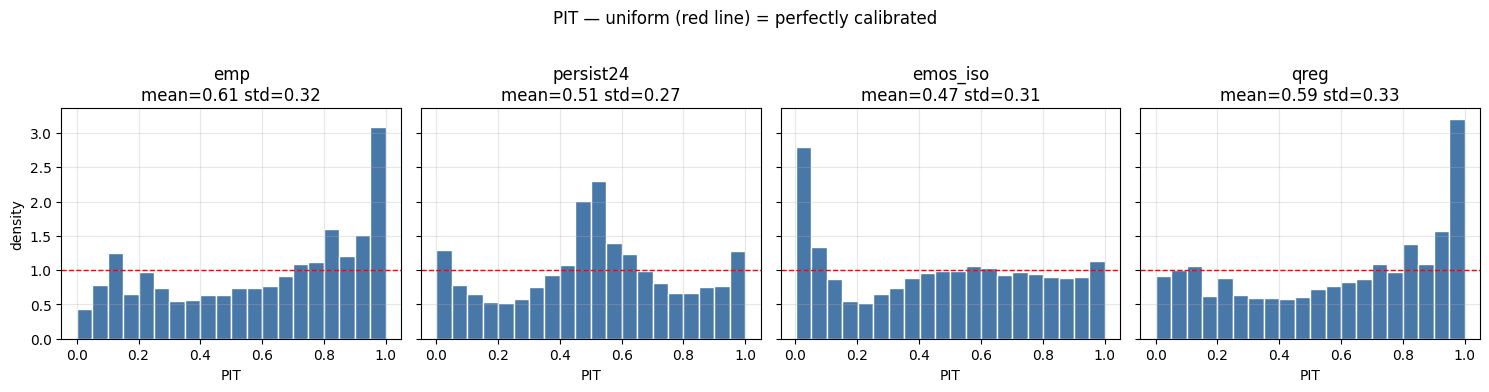

In [7]:
stages_to_plot = ["emp", "persist24", "emos_iso", "qreg"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for ax, name in zip(axes, stages_to_plot, strict=True):
    dist = result[name]
    y_oof = y[dist.ids.astype(int)]
    pit_vals = pit(dist, y_oof)
    ax.hist(pit_vals, bins=20, color="#4878a8",
            edgecolor="white", density=True)
    ax.axhline(1.0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{name}\nmean={pit_vals.mean():.2f} std={pit_vals.std():.2f}")
    ax.set_xlabel("PIT")
axes[0].set_ylabel("density")
plt.suptitle("PIT — uniform (red line) = perfectly calibrated", y=1.02)
plt.tight_layout(); plt.show()

## Predicted bands over time

7 days of held-out predictions from QuantileReg vs realised rentals.
Persistence-24's median is drawn alongside so you can see how often
"yesterday at this hour" misses today.

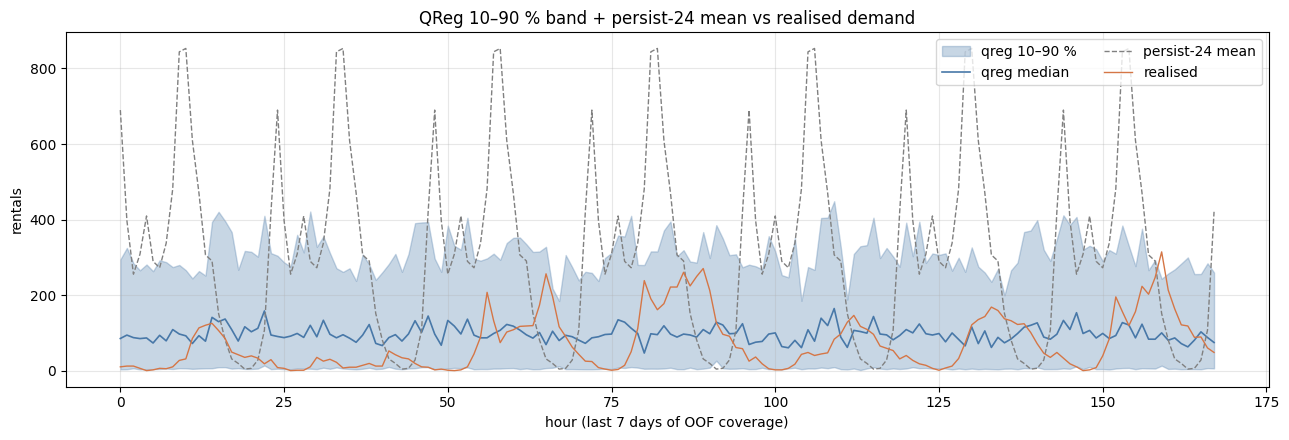

In [8]:
dist_qreg = result["qreg"]
dist_per = result["persist24"]

# Take the last 7 days of OOF coverage shared by both stages.
ids_qreg = dist_qreg.ids.astype(int)
ids_per = dist_per.ids.astype(int)
common = np.intersect1d(ids_qreg, ids_per)
last_week = common[-24 * 7:]

pos_q = np.searchsorted(ids_qreg, last_week)
pos_p = np.searchsorted(ids_per, last_week)
taus = dist_qreg.taus
i_lo = np.argmin(np.abs(taus - 0.1))
i_md = np.argmin(np.abs(taus - 0.5))
i_hi = np.argmin(np.abs(taus - 0.9))

xs = np.arange(last_week.size)
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.fill_between(xs,
                dist_qreg.qvals[pos_q, i_lo],
                dist_qreg.qvals[pos_q, i_hi],
                alpha=0.3, color="#4878a8", label="qreg 10–90 %")
ax.plot(xs, dist_qreg.qvals[pos_q, i_md], color="#4878a8",
        lw=1.2, label="qreg median")
ax.plot(xs, dist_per.params["mu"][pos_p], color="gray", lw=1,
        linestyle="--", label="persist-24 mean")
ax.plot(xs, y[last_week], color="#d57646", lw=1, label="realised")
ax.set_xlabel("hour (last 7 days of OOF coverage)")
ax.set_ylabel("rentals")
ax.set_title("QReg 10–90 % band + persist-24 mean vs realised demand")
ax.legend(loc="upper right", ncol=2)
plt.tight_layout(); plt.show()

## Reliability diagram (per-bracket)

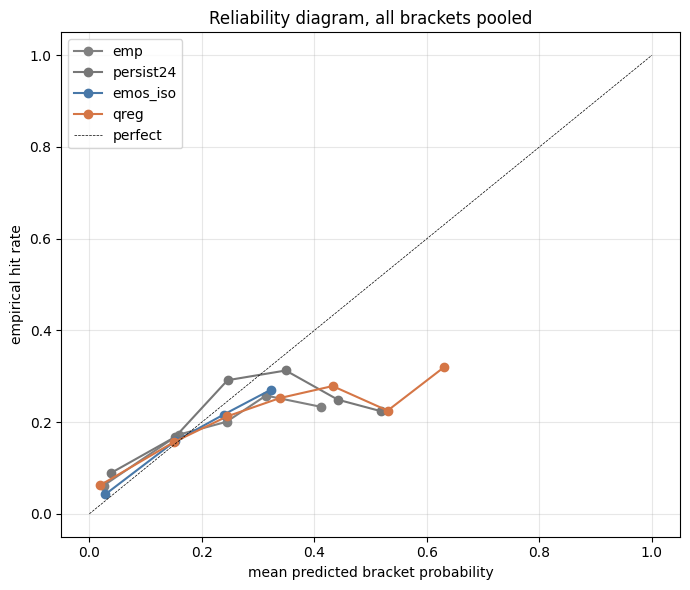

In [9]:
def reliability(dist, ladder, y_oof, n_bins=10):
    cdf_hi = dist.cdf(ladder.edges[1:])
    cdf_lo = dist.cdf(ladder.edges[:-1])
    probs = np.clip(cdf_hi - cdf_lo, 0, 1)
    bin_idx = np.searchsorted(ladder.edges, y_oof, side="right") - 1
    bin_idx = np.clip(bin_idx, 0, probs.shape[1] - 1)
    realized = np.zeros_like(probs)
    realized[np.arange(probs.shape[0]), bin_idx] = 1.0
    p_flat = probs.reshape(-1)
    r_flat = realized.reshape(-1)
    edges_p = np.linspace(0, 1, n_bins + 1)
    means, hits = [], []
    for i in range(n_bins):
        mask = (p_flat >= edges_p[i]) & (p_flat < edges_p[i + 1] + (i == n_bins - 1))
        if mask.sum() < 5:
            continue
        means.append(p_flat[mask].mean())
        hits.append(r_flat[mask].mean())
    return np.array(means), np.array(hits)


fig, ax = plt.subplots(figsize=(7, 6))
for name, color in zip(
    ["emp", "persist24", "emos_iso", "qreg"],
    ["gray", "#777", "#4878a8", "#d57646"], strict=True,
):
    dist = result[name]
    y_oof = y[dist.ids.astype(int)]
    mp, hr = reliability(dist, ladder, y_oof)
    ax.plot(mp, hr, "o-", color=color, label=name)
ax.plot([0, 1], [0, 1], "k--", lw=0.5, label="perfect")
ax.set_xlabel("mean predicted bracket probability")
ax.set_ylabel("empirical hit rate")
ax.set_title("Reliability diagram, all brackets pooled")
ax.legend()
plt.tight_layout(); plt.show()

## Leaderboard

Wider model zoo against the two baselines, ranked by CRPS.

rank model                   CRPS    vs emp   vs P-24
-----------------------------------------------------
1    QuantileReg           100.82    +0.058    +0.013
2    EMOS+Iso              101.60    +0.051    +0.005
3    Persist-24            102.11    +0.046    +0.000
4    CumBinary             102.66    +0.041    -0.005
5    Empirical             107.05    +0.000    -0.048
6    Persist-168           107.45    -0.004    -0.052
7    Persist-1             130.29    -0.217    -0.276


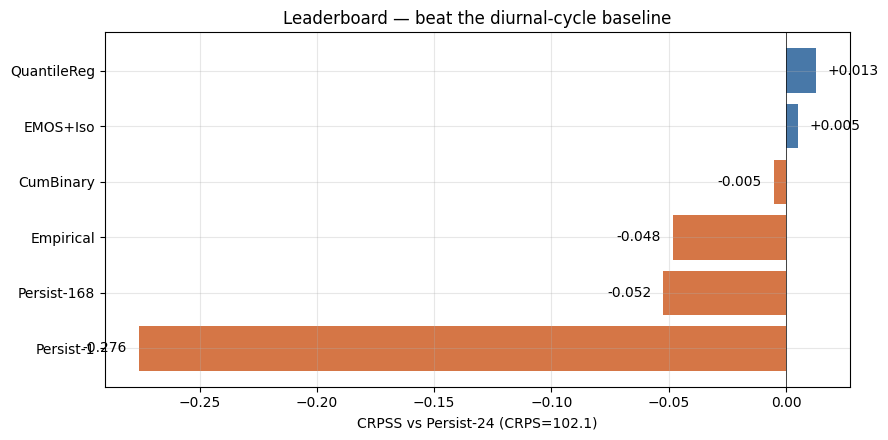

In [10]:
from bracketlearn.trainers import CumulativeBinary

cuts = edges[1:-1]

# Note: `MixtureNormals` was dropped from this leaderboard. Even though
# `X_ens` here is built from three jittered temperature columns (a
# legitimate ensemble shape), the columns predict *temperature*, not
# the target (rental count). The mixture would centre on temp values
# in [0, 50] while y is in [0, 977] — uninterpretable. See
# `leaderboard_zoo.ipynb` for a meaningful use built on top of upstream
# DistForecaster predictions of y.


def _score_one(stage_name, forecaster, x_in=None):
    p = ForecastPipeline(
        steps=[(stage_name, forecaster)],
        cv="expanding-window", n_folds=5, embargo=24,
        refit_on_full=False,
    )
    r = p.fit_predict(x_in if x_in is not None else X_ens,
                      y, ids=ids, timestamps=ts)
    return r.score(y, metrics=["crps"])[stage_name]["crps"]


lb = {
    "Empirical":      _score_one("emp", EmpiricalDistribution()),
    "Persist-1":      _score_one("p1", LiftedForecaster(
        Persistence(lag=1), GlobalResidual(), name="p1",
    )),
    "Persist-24":     _score_one("p24", LiftedForecaster(
        Persistence(lag=24), GlobalResidual(), name="p24",
    )),
    "Persist-168":    _score_one("p168", LiftedForecaster(
        Persistence(lag=168), GlobalResidual(), name="p168",
    )),
    "EMOS+Iso":       _score_one("emos_iso", CalibratedForecaster(
        EMOS(), Isotonic(edges=edges), name="emos_iso",
    )),
    "QuantileReg":    _score_one("qreg", QuantileReg(
        n_estimators=200, learning_rate=0.05, random_seed=0,
    ), x_in=X),
    "CumBinary":      _score_one("cum", CumulativeBinary(
        cutpoints=cuts, outer_edges=(float(edges[0]), float(edges[-1])),
        n_estimators=80,
    ), x_in=X),
}

rows = sorted(lb.items(), key=lambda kv: kv[1])
base = lb["Empirical"]
seas = lb["Persist-24"]
print(f"{'rank':<5}{'model':<18}{'CRPS':>10}{'vs emp':>10}{'vs P-24':>10}")
print("-" * 53)
for i, (name, c) in enumerate(rows, 1):
    print(f"{i:<5}{name:<18}{c:>10.2f}"
          f"{1-c/base:>+10.3f}{1-c/seas:>+10.3f}")

# Bars vs the seasonal baseline (the harder one).
fig, ax = plt.subplots(figsize=(9, 4.5))
names = [r[0] for r in rows if r[0] != "Persist-24"]
skills = [1 - r[1]/seas for r in rows if r[0] != "Persist-24"]
colors = ["#4878a8" if s > 0 else "#d57646" for s in skills]
ax.barh(names, skills, color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_xlabel(f"CRPSS vs Persist-24 (CRPS={seas:.1f})")
ax.set_title("Leaderboard — beat the diurnal-cycle baseline")
for i, s in enumerate(skills):
    ax.text(s + (0.005 if s > 0 else -0.005), i,
            f"{s:+.3f}", va="center",
            ha="left" if s > 0 else "right")
plt.tight_layout(); plt.show()

## Point-forecast benchmark — classical regression view

Collapse each predictive distribution to its mean → score with RMSE/MAE
and compare against sklearn's `Ridge` and LightGBM trained with the
same expanding-window splits. This is the "does my probabilistic stack
beat plain regression on classical metrics?" check.

rank model                         RMSE       MAE
-------------------------------------------------
1    sklearn Ridge               186.23    144.51
2    EMOS+Iso (→mean)            187.21    149.48
3    LightGBM                    189.08    146.97
4    Persist-24 (→mean)          191.79    130.32
5    QuantileReg (→mean)         194.77    144.12
6    Empirical (→mean)           200.45    148.79


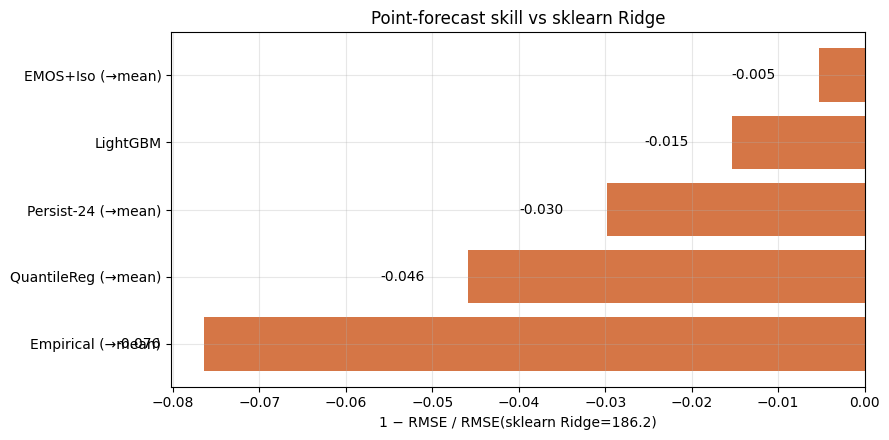

In [11]:
from bracketlearn.score import to_point
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit


# Reuse the dists from the leaderboard pipelines above where convenient;
# for sklearn baselines walk the same expanding splits the pipeline used.
def _point_metrics_from_dist(dist, y_full):
    y_oof = y_full[dist.ids.astype(int)]
    mu = to_point(dist, how="mean")
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_oof, mu))),
        "MAE":  float(mean_absolute_error(y_oof, mu)),
    }


# We already have OOF dists for emp, persist24, emos_iso, qreg in `result`.
prob_point = {
    "Empirical (→mean)":   _point_metrics_from_dist(result["emp"], y),
    "Persist-24 (→mean)":  _point_metrics_from_dist(result["persist24"], y),
    "EMOS+Iso (→mean)":    _point_metrics_from_dist(result["emos_iso"], y),
    "QuantileReg (→mean)": _point_metrics_from_dist(result["qreg"], y),
}


# Classical sklearn regressors over the same expanding-window splits the
# pipeline uses internally. TimeSeriesSplit is the sklearn equivalent.
def _sklearn_oof(model_factory, X_in):
    tss = TimeSeriesSplit(n_splits=5)
    preds = np.full(y.size, np.nan)
    for tr, te in tss.split(X_in):
        m = model_factory()
        m.fit(X_in[tr], y[tr])
        preds[te] = m.predict(X_in[te])
    mask = ~np.isnan(preds)
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y[mask], preds[mask]))),
        "MAE":  float(mean_absolute_error(y[mask], preds[mask])),
    }


prob_point["sklearn Ridge"] = _sklearn_oof(
    lambda: Ridge(alpha=1.0), X,    # raw feature matrix, not the X_ens
)
prob_point["LightGBM"] = _sklearn_oof(
    lambda: LGBMRegressor(n_estimators=200, learning_rate=0.05,
                          verbose=-1, random_state=0),
    X,
)

rows_pt = sorted(prob_point.items(), key=lambda kv: kv[1]["RMSE"])
print(f"{'rank':<5}{'model':<24}{'RMSE':>10}{'MAE':>10}")
print("-" * 49)
for i, (name, m) in enumerate(rows_pt, 1):
    print(f"{i:<5}{name:<24}{m['RMSE']:>10.2f}{m['MAE']:>10.2f}")

sk_rmse = prob_point["sklearn Ridge"]["RMSE"]
names_pt = [r[0] for r in rows_pt if r[0] != "sklearn Ridge"]
skills_pt = [1 - r[1]["RMSE"]/sk_rmse for r in rows_pt if r[0] != "sklearn Ridge"]
fig, ax = plt.subplots(figsize=(9, 4.5))
colors_pt = ["#4878a8" if s > 0 else "#d57646" for s in skills_pt]
ax.barh(names_pt, skills_pt, color=colors_pt)
ax.axvline(0, color="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_xlabel(f"1 − RMSE / RMSE(sklearn Ridge={sk_rmse:.1f})")
ax.set_title("Point-forecast skill vs sklearn Ridge")
for i, s in enumerate(skills_pt):
    ax.text(s + (0.005 if s > 0 else -0.005), i, f"{s:+.3f}",
            va="center", ha="left" if s > 0 else "right")
plt.tight_layout(); plt.show()